- (참고)ImageDataGenerator.flow_from_directory : https://cafe.daum.net/flowlife/S2Ul/59

### ImageDataGenerator 메서드
 - apply_transform : 주어진 매개변수에 따라 이미지에 변형을 가함.
 - fit : 샘플 데이터에 데이터 생성기를 학습시킴.
 - flow : 데이터와 라벨 배열을 받아 증강된 데이터의 배치를 생성함.
 - flow_from_dataframe : dataframe과 디렉토리의 위치를 전달받아 증강/정규화된 데이터의 배치를 생성함.
 - **flow_from_directory** : 디렉토리의 경로를 전달받아 증강된 데이터의 배치(batch)를 생성함.
    - 이미지들이 다 여기에 저장되어 있어
    - 디렉토리를 이용해서 레이블을 읽어 올 수 있다
 - get_random_transform : 변형에 대한 무작위 매개변수를 생성함.
 - random_transform : 이미지에 무작위 변형을 적용함.
 - standardize : 인풋의 배치에 정규화 구성을 적용함.
 ---
 ## CNN : 개/고양이 이미지 이진분류 하기(고해상도)
 - pip install tensorflow_datasets 필요

In [1]:
# !pip install tensorflow_datasets

In [2]:
import os
# shutil : file/folder를 이동, 복사, 삭제할 때 사용
# ex)shutil.copy('a.txt','b.txt') ...
import shutil

import tensorflow_datasets as tfds
print(tfds.list_builders()) # tfds에서 제공하는 공개데이터 셋(이미지, 텍스트, 사운드, 번역을위한 데이터, 강화학습을 위한 데이터...)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(1)
tf.random.set_seed(1)


['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset', 'ai2_arc', 'ai2_arc_with_ir', 'ai2dcaption', 'aloha_mobile', 'amazon_us_reviews', 'anli', 'answer_equivalence', 'arc', 'asimov_dilemmas_auto_val', 'asimov_dilemmas_scifi_train', 'asimov_dilemmas_scifi_val', 'asimov_injury_val', 'asimov_multimodal_auto_val', 'asimov_multimodal_manual_val', 'asqa', 'asset', 'assin2', 'asu_table_top_converted_externally_to_rlds', 'austin_buds_dataset_converted_externally_to_rlds', 'austin_sailor_dataset_converted_externally_to_rlds', 'austin_sirius_dataset_converted_externally_to_rlds', 'bair_robot_pushing_small', 'bc_z', 'bccd', 'beans', 'bee_dataset', 'beir', 'berkeley_autolab_ur5', 'berkeley_cable_routing', 'berkeley_fanuc_manipulation', 'berkeley_gnm_cory_hall', 'berkeley_gnm_recon', 'berkeley_gnm_sac_son', 'berkeley_mvp_converted_externally_to_rlds', 'berkeley_rpt_converted_externally_to_rlds', 'big_patent', 'bigearthnet', 'billsum', 'binarized_mnist', 'binary_alpha_digits', 'b

In [3]:
# data download - tf에서 권장하는 방법
# with_info=True : dataset info()를 반환
# as_supervised=True : data를 (image, label)형태로 반환
(dataset, info) = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)
print(dataset)
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.CTGR1T_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuf

label_name ['cat', 'dog']
dict_keys([Split('train')])
(375, 500, 3) <dtype: 'uint8'>
0


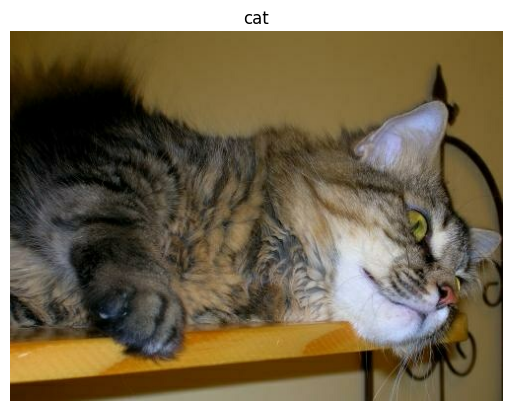

In [4]:
label_names = info.features['label'].names
print('label_name', label_names) # ['cat', 'dog']
print(dataset.keys()) # train만 지원 [Split('train')]

for image, label in dataset['train'].skip(3).take(1): # 몇번째, 몇개
  print(image.shape, image.dtype)
  print(label.numpy()) # 1
  plt.imshow(image)
  plt.title(label_names[label.numpy()])
  plt.axis('off')
  plt.show()


In [5]:
# 폴더(디렉토리) 구조를 생성
# 이미지 root 폴더
base_dir = './cats_and_dogs_filtered'

# train data 만들 폴더 - 학습을 위한 이미지 폴더
train_dir = os.path.join(base_dir, 'train')

# validation data 만들 폴더 - 검증을 위한 이미지 폴더
validation_dir = os.path.join(base_dir, 'validation')

# train폴더 안에 cat / dog 나누기
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# validation 폴더 밑에 cat / dog 나누기
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

# 폴더(디렉토리)가 없을때 생성
for d in [train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir]:
  os.makedirs(d, exist_ok=True)

# --------------------------------------------------------------------------------------
# train / validation 분할 + 이미지 저장
IMG_SIZE = (150, 150)

def save_imageFunc(img, label, idx, split):

  # 이미지 크기 조정
  img = tf.image.resize(img, IMG_SIZE)
  # tensor를 정수형 이미지로 변환해 numpy 배열로 반환
  # ex) 0.12 -> 0, 255.0 -> 255
  img = tf.cast(img, tf.uint8).numpy()

  # 폴더 경로 정해주기
  if split == 'train':
    folder = train_cats_dir if label == 0 else train_dogs_dir
  else:
    folder = val_cats_dir if label == 0 else val_dogs_dir

  path = os.path.join(folder, f'{idx}.jpg') # 이미지 저장 경로
  # 이미지 저장
  tf.keras.preprocessing.image.save_img(path, img) # 이미지가 해당 경로에 저장



# train data의 일부를 validation으로 사용 (8:2)
total = info.splits['train'].num_examples # 전체 갯수 확인
print(total) # 23262

train_size = int(0.8 * total)
print(train_size) # 18609

for i , (img, label) in enumerate(dataset['train']):
  if i < train_size:
    save_imageFunc(img, label, i, 'train')
  else:
    save_imageFunc(img, label, i, 'val')

print('데이터 준비 완료')

23262
18609
데이터 준비 완료


In [6]:
PATH = './cats_and_dogs_filtered'
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

# 디렉토리 경로 유무 확인
for p in [train_dir, train_cats_dir, train_dogs_dir, validation_dir, val_cats_dir, val_dogs_dir]:
  print(p, ' -> ', os.path.exists(p))

# 데이터 비율 확인하기 - 분포 확인
print('cats(train) :', len(os.listdir(train_cats_dir)))
print('dogs(train) :', len(os.listdir(train_dogs_dir)))
print('cats(val) :', len(os.listdir(val_cats_dir)))
print('dogs(val) :', len(os.listdir(val_dogs_dir)))


./cats_and_dogs_filtered/train  ->  True
./cats_and_dogs_filtered/train/cats  ->  True
./cats_and_dogs_filtered/train/dogs  ->  True
./cats_and_dogs_filtered/validation  ->  True
./cats_and_dogs_filtered/validation/cats  ->  True
./cats_and_dogs_filtered/validation/dogs  ->  True
cats(train) : 9381
dogs(train) : 9228
cats(val) : 2277
dogs(val) : 2376


In [7]:
# Colab에서 폴더 전체를 내PC로 다운로드하기
import shutil
from google.colab import files

shutil.make_archive(
          'cats_and_dogs_filtered',   # 생성될 zip 파일 이름
          'zip',                      # 압축 형식
          './cats_and_dogs_filtered'  # 압축할 폴더명
)

files.download('cats_and_dogs_filtered.zip') # 내 PC로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# 이미지 증강 / 스케일링
IMG_HEIGHT, IMG_WIDEH = 150, 150
BATCH_SIZE = 128
EPOCHS = 50 # 실제는 더 큰 수를 사용

train_datagen = ImageDataGenerator(
    rescale=1./255,           # 스케일(이미지 px값을 [0. ~ 1.]로 조정)
    rotation_range=15,        # 회전
    width_shift_range=0.1,    # 평행이동
    height_shift_range=0.1,   # 평행이동
    horizontal_flip=True      # 좌우반전
)

val_datagen = ImageDataGenerator(rescale=1./255) # 검증용 데이터는 스케일만 사용

# 자동 라벨링
# flow_from_directory : 폴더를 자동 라벨링하여 로드
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDEH),
    batch_size=BATCH_SIZE,
    class_mode='binary', # 이진분류 (다중분류는 categorycal)
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDEH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('class_indices :', train_data.class_indices) # class_indices : {'cats': 0, 'dogs': 1}

Found 18609 images belonging to 2 classes.
Found 4653 images belonging to 2 classes.
class_indices : {'cats': 0, 'dogs': 1}


idx_to_name : {0: 'cats', 1: 'dogs'}


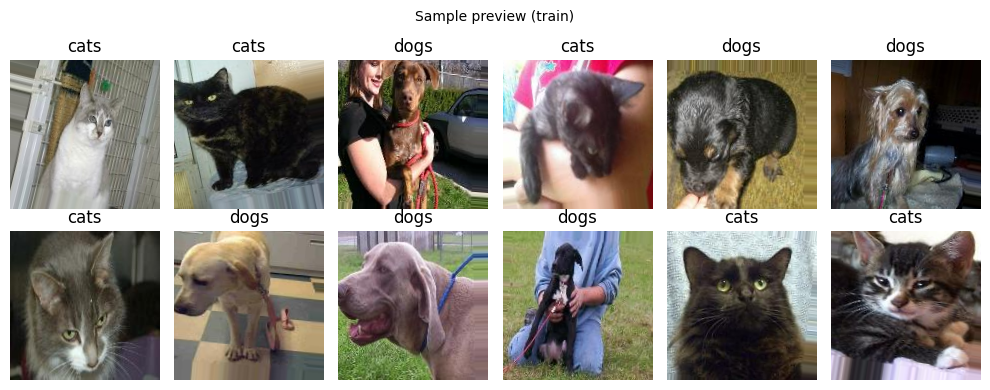

In [9]:
# 로드된 이미지 한개의 배치 확인(미리보기)
imgs, labels = next(train_data)
n_show = min(12, imgs.shape[0]) # 보여줄 샘플 수
cols = 6
rows = int(np.ceil(n_show / cols)) # 행 수
idx_to_name = {value:key for key, value in train_data.class_indices.items()}
print('idx_to_name :', idx_to_name) # idx_to_name : {0: 'cats', 1: 'dogs'} # key : value를 뒤집음 - 시각화를 위한 준비

plt.figure(figsize=(10, 2 * rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(imgs[i])
  ax.set_title(f'{idx_to_name[int(labels[i])]}')
  ax.axis('off') # 축 X
plt.suptitle('Sample preview (train)', fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# 모델 정의하기
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDEH, 3)),

    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(), # feature map에 절반크기로 Down Sampling됨

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Flatten(), # 2d -> 1d(FC Layer)

    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
# complie / fit
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# callback 사전 설정하기
os.makedirs('./chkpoints', exist_ok=True)
ckpt = ModelCheckpoint(
    filepath='./chkpoints/catdog_best.keras',
    monitor='val_accuracy',
    mode= 'max',
    save_best_only=True,
    verbose=1
)
es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# fit
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=[ckpt, es],
    verbose=2
)

Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.69031, saving model to ./chkpoints/catdog_best.keras

Epoch 1: finished saving model to ./chkpoints/catdog_best.keras
146/146 - 125s - 854ms/step - accuracy: 0.6019 - loss: 0.7211 - val_accuracy: 0.6903 - val_loss: 0.5926
Epoch 2/50

Epoch 2: val_accuracy improved from 0.69031 to 0.73501, saving model to ./chkpoints/catdog_best.keras

Epoch 2: finished saving model to ./chkpoints/catdog_best.keras
146/146 - 112s - 769ms/step - accuracy: 0.7042 - loss: 0.5717 - val_accuracy: 0.7350 - val_loss: 0.5389
Epoch 3/50

Epoch 3: val_accuracy improved from 0.73501 to 0.75177, saving model to ./chkpoints/catdog_best.keras

Epoch 3: finished saving model to ./chkpoints/catdog_best.keras
146/146 - 112s - 768ms/step - accuracy: 0.7375 - loss: 0.5248 - val_accuracy: 0.7518 - val_loss: 0.5002
Epoch 4/50

Epoch 4: val_accuracy improved from 0.75177 to 0.80056, saving model to ./chkpoints/catdog_best.keras

Epoch 4: finished saving model to ./chk

검증 평가 결과 
val_loss : 0.2261 val_acc :0.9069


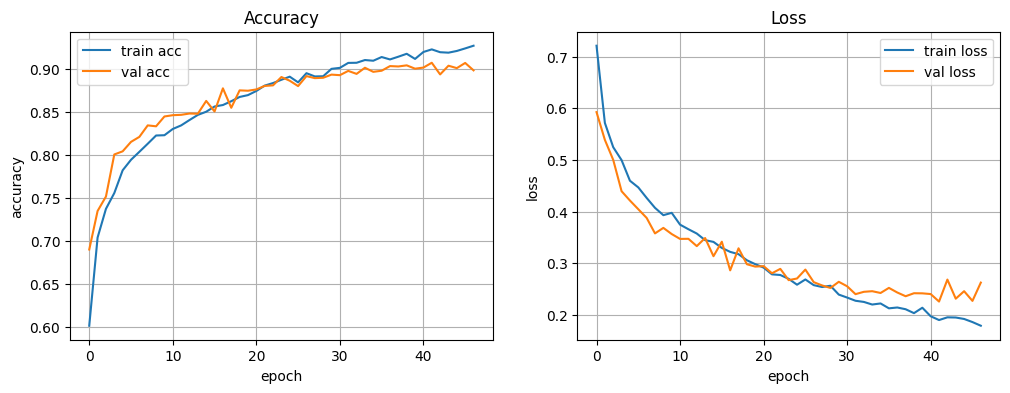

In [12]:
# 평가
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f'검증 평가 결과 \nval_loss : {val_loss:.4f} val_acc :{val_acc:.4f}')

# 학습 곡선 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

Found 4653 images belonging to 2 classes.


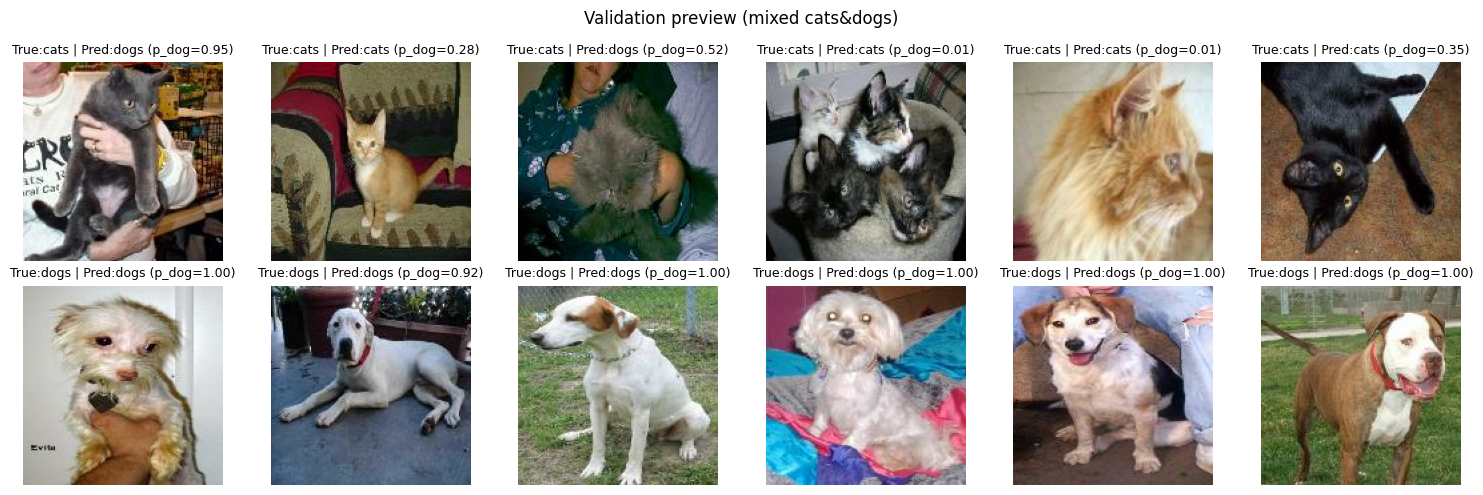

In [13]:
# 검증 배치 예측확인하기
preview_gen = ImageDataGenerator(rescale=1./255)

# 미리보기 전용 - 데이터를 섞어서 배치 뽑기 진행 - 평가용 데이터는 원래대로 유지하고 미리보기용 추출
preview_flow = preview_gen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDEH),
    batch_size=24,
    class_mode='binary',
    shuffle=True, # 섞어서 검증 배치 뽑기
    seed=123
)

# 예측용 cat / dog 보기(6개)
n_each = 6        # cat/dog각각 n개를 모을때 까지 여러 배치 이어받기(디렉토리에서 부분부분 진행함)

cats_images, dogs_images = [], [] # 두개의 담을 변수 생성

while len(cats_images) < n_each or len(dogs_images) < n_each:
  # 섞어놓은 배치에서 읽어옴
  imgs, labels = next(preview_flow)
  # 배치 내에서 이미지를 하나씩 살펴보며 cats/dogs 리스트에 채우기
  for image, label in zip(imgs, labels.ravel()):
    # cats_images가 n_each 보다 작으면 append
    if label==0 and len(cats_images) < n_each:
      cats_images.append(image)
    # dogs_images가 n_each 보다 작으면 append
    elif label==1 and len(dogs_images) < n_each:
      dogs_images.append(image)
    # 다 찼으면
    if len(cats_images) >= n_each and len(dogs_images) >= n_each:
      break

# 예측
cats_probs = model.predict(np.array(cats_images), verbose=0).ravel()
dogs_probs = model.predict(np.array(dogs_images), verbose=0).ravel()

# 예측 결과 시각화(0행:고양이, 1행:강아지)
rows, cols = 2, n_each
plt.figure(figsize=(2.5*cols, 5))
for i in range(n_each):
  # cats row
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(cats_images[i])
  ax.axis('off')
  p = cats_probs[i]
  ax.set_title(f'True:cats | Pred:{'dogs' if p>=0.5 else 'cats'} (p_dog={p:.2f})',fontsize=9)

  # dogs row
  ax = plt.subplot(rows, cols, cols+i+1)
  ax.imshow(dogs_images[i])
  ax.axis('off')
  p = dogs_probs[i]
  ax.set_title(f'True:dogs | Pred:{'dogs' if p>=0.5 else 'cats'} (p_dog={p:.2f})',fontsize=9)

plt.suptitle('Validation preview (mixed cats&dogs)', fontsize=12)
plt.tight_layout()
plt.show()
